<a href="https://colab.research.google.com/github/UnaSun2025/MSSP6070/blob/main/Week_06_Data_Cleaning_and_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning and Preparation

During data analysis, much time is spent cleaning and transforming data into a consumable format.  Research suggests that as much as 80% of a data scientist/analyst’s time is spent cleaning and transforming data.

Content modified from:
1.  McKinney, W. (2018). Python for data analysis. Ch. 07. O'Reilly Media.

2.   Powerful Python data analysis toolkit, Release 1.3.4. See https://pandas.pydata.org/pandas-docs/version/1.3.4/pandas.pdf

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pushd "/content/drive/MyDrive/MSSP607/Modules/Week06"

/content/drive/MyDrive/MSSP607/Modules/Week06


['/content']

In [3]:
import numpy as np
import pandas as pd
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

## Handling Missing Data

In [4]:
string_data = pd.Series(['aardvark', 'artichoke', np.nan, 'avocado'])
string_data
string_data.isnull()

,0
0,False
1,False
2,True
3,False


In [6]:
string_data[0] = None #change variable0 into None and others uncahnge
string_data.isnull()

,0
0,True
1,False
2,True
3,False


### Filtering Out Missing Data

In [7]:
from numpy import nan as NA
data = pd.Series([1, NA, 3.5, NA, 7])
data.dropna() #drop the na result

,0
0,1.0
2,3.5
4,7.0


In [11]:
data[data.notnull()] # metain the variable with value

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [12]:
data = pd.DataFrame([[1., 6.5, 3.], [1., NA, NA],
                     [NA, NA, NA], [NA, 6.5, 3.]]) # dataframe is a collection series
cleaned = data.dropna() #drop row with any NA
data
cleaned

,0,1,2
0,1.0,6.5,3.0


In [13]:
data.dropna(how='all')# only drop with all NA

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
3,NaN,6.5,3.0


In [17]:
data[4] = NA #make a new row, all elements are NA
data
data.dropna(axis=1, how='all') #axis=1: check by colunmn:axis=0: check by colunmn
#drop NA but not NaN

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [18]:
df = pd.DataFrame(np.random.randn(7, 3))
df.iloc[:4, 1] = NA #第 1 列（第二列）前 4 行设置为 NA;即第 0,1,2,3 行的第 1 列 = NaN
df.iloc[:2, 2] = NA #第 2 列（第三列）前 2 行设置为 NA;即第 0,1 行的第 2 列 = NaN
df
df.dropna() #delete row with any NaN
df.dropna(thresh=2) #thresh=2 = 保留至少有 2 个非 NaN 值的行

,0,1,2
2,0.092908,NaN,0.769023
3,1.246435,NaN,-1.296221
4,0.274992,0.228913,1.352917
5,0.886429,-2.001637,-0.371843
6,1.669025,-0.438570,-0.539741


### Filling In Missing Data

In [ ]:
df.fillna(0)

,0,1,2
0,-0.204708,0.000000,0.000000
1,-0.555730,0.000000,0.000000
2,0.092908,0.000000,0.769023
3,1.246435,0.000000,-1.296221
4,0.274992,0.228913,1.352917
5,0.886429,-2.001637,-0.371843
6,1.669025,-0.438570,-0.539741


In [ ]:
df.fillna({1: 0.5, 2: 0})

,0,1,2
0,-0.204708,0.500000,0.000000
1,-0.555730,0.500000,0.000000
2,0.092908,0.500000,0.769023
3,1.246435,0.500000,-1.296221
4,0.274992,0.228913,1.352917
5,0.886429,-2.001637,-0.371843
6,1.669025,-0.438570,-0.539741


In [ ]:
_ = df.fillna(0, inplace=True)
df

,0,1,2
0,-0.204708,0.000000,0.000000
1,-0.555730,0.000000,0.000000
2,0.092908,0.000000,0.769023
3,1.246435,0.000000,-1.296221
4,0.274992,0.228913,1.352917
5,0.886429,-2.001637,-0.371843
6,1.669025,-0.438570,-0.539741


In [ ]:
df = pd.DataFrame(np.random.randn(6, 3))
df.iloc[2:, 1] = NA
df.iloc[4:, 2] = NA
df
df.fillna(method='ffill')
df.fillna(method='ffill', limit=2)

<ipython-input-197-71ad143e3b5c>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')
<ipython-input-197-71ad143e3b5c>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', limit=2)


,0,1,2
0,0.476985,3.248944,-1.021228
1,-0.577087,0.124121,0.302614
2,0.523772,0.124121,1.343810
3,-0.713544,0.124121,-2.370232
4,-1.860761,NaN,-2.370232
5,-1.265934,NaN,-2.370232


In [ ]:
data = pd.Series([1., NA, 3.5, NA, 7])
data.fillna(data.mean())

,0
0,1.000000
1,3.833333
2,3.500000
3,3.833333
4,7.000000


## Data Transformation

### Removing Duplicates

In [36]:
data = pd.DataFrame({'k1': ['one', 'two'] * 3 + ['two'],
                     'k2': [1, 1, 2, 3, 3, 4, 4]})
data

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4
6,two,4


In [37]:
data.duplicated()
#row5 and row6 are the same

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,True


In [38]:
data.drop_duplicates()
#drop the row6

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4


In [39]:
data['v1'] = range(7)
data.drop_duplicates(['k1'])

,k1,k2,v1
0,one,1,0
1,two,1,1


In [26]:
data.drop_duplicates(['k1', 'k2'], keep='last')#keep the last occupied row, delete the fisrt occur row

,k1,k2,v1
0,one,1,0
1,two,1,1
2,one,2,2
3,two,3,3
4,one,3,4
6,two,4,6


### Transforming Data Using a Function or Mapping

In [27]:
data = pd.DataFrame({'food': ['bacon', 'pulled pork', 'bacon',
                              'Pastrami', 'corned beef', 'Bacon',
                              'pastrami', 'honey ham', 'nova lox'],
                     'ounces': [4, 3, 12, 6, 7.5, 8, 3, 5, 6]})
data

,food,ounces
0,bacon,4.0
1,pulled pork,3.0
2,bacon,12.0
3,Pastrami,6.0
4,corned beef,7.5
5,Bacon,8.0
6,pastrami,3.0
7,honey ham,5.0
8,nova lox,6.0


In [28]:
meat_to_animal = {
  'bacon': 'pig',
  'pulled pork': 'pig',
  'pastrami': 'cow',
  'corned beef': 'cow',
  'honey ham': 'pig',
  'nova lox': 'salmon'
} # the data type is dictionaries

In [31]:
lowercased = data['food'].str.lower() #change uppercase into lowercase
lowercased
data['animal'] = lowercased.map(meat_to_animal)
data

,food,ounces,animal
0,bacon,4.0,pig
1,pulled pork,3.0,pig
2,bacon,12.0,pig
3,Pastrami,6.0,cow
4,corned beef,7.5,cow
5,Bacon,8.0,pig
6,pastrami,3.0,cow
7,honey ham,5.0,pig
8,nova lox,6.0,salmon


In [30]:
data['food'].map(lambda x: meat_to_animal[x.lower()])
#map(...): Applies a function to each element in the column
#lambda x: meat_to_animal[x.lower()]: For each value x in "food":Convert x to lowercase (x.lower())
#second, Look up the corresponding animal in the dictionary meat_to_animal
#lambda function: (lambda x:     ) call a row/column in a easy way

,food
0,pig
1,pig
2,pig
3,cow
4,cow
5,pig
6,cow
7,pig
8,salmon


### Replacing Values

In [40]:
data = pd.Series([1., -999., 2., -999., -1000., 3.])
data

,0
0,1.0
1,-999.0
2,2.0
3,-999.0
4,-1000.0
5,3.0


In [42]:
data.replace(-999, np.nan) #replace -999 into NaN

,0
0,1.0
1,NaN
2,2.0
3,NaN
4,-1000.0
5,3.0


In [43]:
data.replace([-999, -1000], np.nan) #replace -999 and -1000 into NaN

,0
0,1.0
1,NaN
2,2.0
3,NaN
4,NaN
5,3.0


In [44]:
data.replace([-999, -1000], [np.nan, 0]) #replace -999 into NaN and -1000 into 0

,0
0,1.0
1,NaN
2,2.0
3,NaN
4,0.0
5,3.0


In [45]:
data.replace({-999: np.nan, -1000: 0})

,0
0,1.0
1,NaN
2,2.0
3,NaN
4,0.0
5,3.0


### Renaming Axis Indexes

In [46]:
data = pd.DataFrame(np.arange(12).reshape((3, 4)),
                    index=['Ohio', 'Colorado', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
New York,8,9,10,11


In [49]:
transform = lambda x: x[:4].upper() #x[:4]：取字符串前 4 个字符
data.index.map(transform) #map: 这只“映射”但不赋值，因此不会修改原 DataFrame，结果只是显示一个 Index 对象

Index(['OHIO', 'COLO', 'NEW '], dtype='object')

In [50]:
data.index = data.index.map(transform) # 这一步把映射后的结果重新赋值给 data.index，索引被更新
data

,one,two,three,four
OHIO,0,1,2,3
COLO,4,5,6,7
NEW,8,9,10,11


In [52]:
data.rename(index=str.title, columns=str.upper)
#rename() 可以用来修改 行索引 (index) 和 列名 (columns)，并且可以传入一个函数 对每个元素进行转换。
#.title() 方法: "ohio" → "Ohio"
#.upper() 方法: "one" → "ONE"

,ONE,TWO,THREE,FOUR
Ohio,0,1,2,3
Colo,4,5,6,7
New,8,9,10,11


In [54]:
data.rename(index={'OHIO': 'INDIANA'},
            columns={'three': 'peekaboo'})
#change name
#默认 inplace=False 所以这行不会改变原 DataFrame，只是返回一个“修改后的副本”

,one,two,peekaboo,four
INDIANA,0,1,2,3
COLO,4,5,6,7
NEW,8,9,10,11


In [55]:
data.rename(index={'OHIO': 'INDIANA'}, inplace=True)
data
#inplace=True：原 DataFrame 会被永久修改

,one,two,three,four
INDIANA,0,1,2,3
COLO,4,5,6,7
NEW,8,9,10,11


### Discretization and Binning

In [56]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]

In [58]:
bins = [18, 25, 35, 60, 100]
#bins 区间含义：
#(18, 25]
#(25, 35]
#(35, 60]
#(60, 100]
#默认：左开右闭 ( ) ]
cats = pd.cut(ages, bins)
#pd.cut 分箱
cats

[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

In [60]:
cats.codes #查看数字编码（每个组对应一个数字）
cats.categories #查看分类区间名称
pd.value_counts(cats) #查看每个区间有多少人

/tmp/ipython-input-1439005018.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(cats) #查看每个区间有多少人


,count
"(18, 25]",5
"(25, 35]",3
"(35, 60]",3
"(60, 100]",1


In [61]:
pd.cut(ages, [18, 26, 36, 61, 100], right=False)
#修改 right=False，让区间变为左闭右开 [ )

[[18, 26), [18, 26), [18, 26), [26, 36), [18, 26), ..., [26, 36), [61, 100), [36, 61), [36, 61), [26, 36)]
Length: 12
Categories (4, interval[int64, left]): [[18, 26) < [26, 36) < [36, 61) < [61, 100)]

In [65]:
group_names = ['Youth', 'YoungAdult', 'MiddleAged', 'Senior'] #use these label name replace [18, 26)...
pd.cut(ages, bins, labels=group_names)

['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'YoungAdult', 'Senior', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 12
Categories (4, object): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']

In [64]:
data = np.random.rand(20)
pd.cut(data, 4, precision=2)
#cut(..., 4)：把数据 等宽划分为 4 个区间
#precision=2：区间边界保留 2 位小数

[(0.49, 0.71], (0.041, 0.26], (0.041, 0.26], (0.71, 0.93], (0.49, 0.71], ..., (0.26, 0.49], (0.71, 0.93], (0.041, 0.26], (0.71, 0.93], (0.71, 0.93]]
Length: 20
Categories (4, interval[float64, right]): [(0.041, 0.26] < (0.26, 0.49] < (0.49, 0.71] <
                                           (0.71, 0.93]]

In [63]:
data = np.random.randn(1000)  # Normally distributed
cats = pd.qcut(data, 4)  # Cut into quartiles qcut 的特点：按照数据的实际分布划分，使每个区间内的元素数量尽量相同
cats
pd.value_counts(cats)

/tmp/ipython-input-2613634809.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(cats)


,count
"(-3.746, -0.628]",250
"(-0.628, -0.0221]",250
"(-0.0221, 0.681]",250
"(0.681, 3.26]",250


In [ ]:
pd.qcut(data, [0, 0.1, 0.5, 0.9, 1.]) #自定义分位点列表
#qcut 是“按分位数分箱”

[(-0.0265, 1.286], (-0.0265, 1.286], (-1.187, -0.0265], (-0.0265, 1.286], (-0.0265, 1.286], ..., (-1.187, -0.0265], (-1.187, -0.0265], (-2.9499999999999997, -1.187], (-0.0265, 1.286], (-1.187, -0.0265]]
Length: 1000
Categories (4, interval[float64, right]): [(-2.9499999999999997, -1.187] < (-1.187, -0.0265] < (-0.0265, 1.286] <
                                           (1.286, 3.928]]

### Detecting and Filtering Outliers

In [66]:
data = pd.DataFrame(np.random.randn(1000, 4))
data.describe()

,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.020865,0.041234,-0.036163,-0.033025
std,1.014718,0.990702,0.962020,0.987904
min,-3.645860,-3.333767,-2.901831,-3.428254
25%,-0.662428,-0.610007,-0.702176,-0.731670
50%,0.043579,0.028040,-0.062375,-0.064342
75%,0.723090,0.695298,0.664260,0.625698
max,2.763474,3.525865,2.611678,3.366626


In [ ]:
col = data[2]
col[np.abs(col) > 3]

,2
41,-3.399312
136,-3.745356


In [ ]:
data[(np.abs(data) > 3).any(axis=1)]

,0,1,2,3
41,0.457246,-0.025907,-3.399312,-0.974657
60,1.951312,3.260383,0.963301,1.201206
136,0.508391,-0.196713,-3.745356,-1.520113
235,-0.242459,-3.056990,1.918403,-0.578828
258,0.682841,0.326045,0.425384,-3.428254
322,1.179227,-3.184377,1.369891,-1.074833
544,-3.548824,1.553205,-2.186301,1.277104
635,-0.578093,0.193299,1.397822,3.366626
782,-0.207434,3.525865,0.283070,0.544635
803,-3.645860,0.255475,-0.549574,-1.907459


In [ ]:
data[np.abs(data) > 3] = np.sign(data) * 3
data.describe()

,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.050286,0.025567,-0.001399,-0.051765
std,0.992920,1.004214,0.991414,0.995761
min,-3.000000,-3.000000,-3.000000,-3.000000
25%,-0.599807,-0.612162,-0.687373,-0.747478
50%,0.047101,-0.013609,-0.022158,-0.088274
75%,0.756646,0.695298,0.699046,0.623331
max,2.653656,3.000000,2.735527,3.000000


In [ ]:
np.sign(data).head()

,0,1,2,3
0,-1.0,1.0,-1.0,1.0
1,1.0,-1.0,1.0,-1.0
2,1.0,1.0,1.0,-1.0
3,-1.0,-1.0,1.0,-1.0
4,-1.0,1.0,-1.0,-1.0


### Permutation and Random Sampling

它常用于 打乱行顺序，例如对 df 进行随机重排

permutation:生成新数组

random:直接修改原数组

In [69]:
df = pd.DataFrame(np.arange(5 * 4).reshape((5, 4)))
#np.arange(5 * 4) → 生成 0 到 19 的整数数组
#.reshape((5,4)) → 变成 5 行 4 列的二维数组
#pd.DataFrame(...) → 转成 DataFrame
sampler = np.random.permutation(5)
sampler

array([0, 4, 1, 3, 2])

differences btw take() iloc[] sample()

why rerange the dataframe:

break the bias bring by original range.(students' scores, time series...)

the foundation of sampling

to do Cross-Validation交叉验证

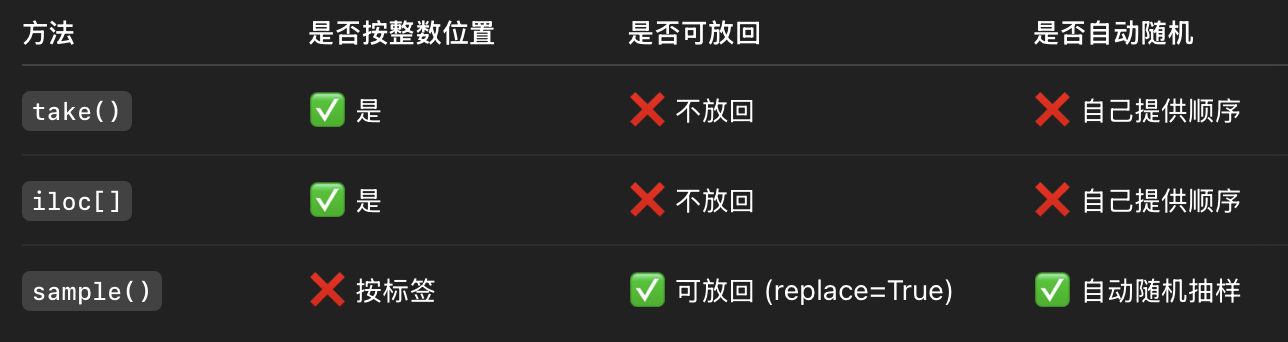

In [71]:
df #查看原始 DataFrame
df.take(sampler) #按指定顺序“重排行” take() 相当于：df 的行顺序被打乱了（洗牌）

,0,1,2,3
0,0,1,2,3
4,16,17,18,19
1,4,5,6,7
3,12,13,14,15
2,8,9,10,11


In [ ]:
df.sample(n=3)

,0,1,2,3
3,12,13,14,15
4,16,17,18,19
2,8,9,10,11


In [ ]:
choices = pd.Series([5, 7, -1, 6, 4])
draws = choices.sample(n=10, replace=True)
draws

,0
4,4
1,7
4,4
2,-1
0,5
3,6
1,7
4,4
0,5
4,4


### Computing Indicator/Dummy Variables

In [ ]:
df = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'b'],
                   'data1': range(6)})
pd.get_dummies(df['key'])

,a,b,c
0,False,True,False
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False
5,False,True,False


In [ ]:
dummies = pd.get_dummies(df['key'], prefix='key')
df_with_dummy = df[['data1']].join(dummies)
df_with_dummy

,data1,key_a,key_b,key_c
0,0,False,True,False
1,1,False,True,False
2,2,True,False,False
3,3,False,False,True
4,4,True,False,False
5,5,False,True,False


In [ ]:

mnames = ['movie_id', 'title', 'genres']
movies = pd.read_table('Examples/movielens/movies.dat', sep='::', engine='python',
                       header=None, names=mnames)
movies[:10]

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [ ]:
all_genres = []
for x in movies.genres:
    all_genres.extend(x.split('|'))
genres = pd.unique(all_genres)

<ipython-input-239-d6c3afc9379b>:4: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  genres = pd.unique(all_genres)


In [ ]:
genres

array(['Animation', "Children's", 'Comedy', 'Adventure', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Sci-Fi', 'Documentary', 'War', 'Musical', 'Mystery', 'Film-Noir',
       'Western'], dtype=object)

In [ ]:
zero_matrix = np.zeros((len(movies), len(genres)))
dummies = pd.DataFrame(zero_matrix, columns=genres)

In [ ]:
gen = movies.genres[0]
gen.split('|')
dummies.columns.get_indexer(gen.split('|'))

array([0, 1, 2])

In [ ]:
for i, gen in enumerate(movies.genres):
    indices = dummies.columns.get_indexer(gen.split('|'))
    dummies.iloc[i, indices] = 1

In [ ]:
movies_windic = movies.join(dummies.add_prefix('Genre_'))
movies_windic.iloc[0]

,0
movie_id,1
title,Toy Story (1995)
genres,Animation|Children's|Comedy
Genre_Animation,1.0
Genre_Children's,1.0
...,...
Genre_War,0.0
Genre_Musical,0.0
Genre_Mystery,0.0
Genre_Film-Noir,0.0


In [ ]:
np.random.seed(12345)
values = np.random.rand(10)
values
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
pd.get_dummies(pd.cut(values, bins))

,"(0.0, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
0,False,False,False,False,True
1,False,True,False,False,False
2,True,False,False,False,False
3,False,True,False,False,False
4,False,False,True,False,False
5,False,False,True,False,False
6,False,False,False,False,True
7,False,False,False,True,False
8,False,False,False,True,False
9,False,False,False,True,False


## String Manipulation

### String Object Methods

In [ ]:
val = 'a,b,  guido'
val.split(',')

['a', 'b', '  guido']

In [ ]:
pieces = [x.strip() for x in val.split(',')]
pieces

['a', 'b', 'guido']

In [ ]:
first, second, third = pieces
first + '::' + second + '::' + third

'a::b::guido'

In [ ]:
'::'.join(pieces)

'a::b::guido'

In [ ]:
'guido' in val
val.index(',')
val.find(':')

-1

In [ ]:
#val.index(':') #Produces an error

In [ ]:
val.count(',')

2

In [ ]:
val.replace(',', '::')
val.replace(',', '')

'ab  guido'

### Regular Expressions

In [ ]:
import re
text = "foo    bar\t baz  \tqux"
re.split('\s+', text)

['foo', 'bar', 'baz', 'qux']

In [ ]:
regex = re.compile('\s+')
regex.split(text)

['foo', 'bar', 'baz', 'qux']

In [ ]:
regex.findall(text)

['    ', '\t ', '  \t']

In [ ]:
text = """Dave dave@google.com
Steve steve@gmail.com
Rob rob@gmail.com
Ryan ryan@yahoo.com
"""
pattern = r'[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,4}'

# re.IGNORECASE makes the regex case-insensitive
regex = re.compile(pattern, flags=re.IGNORECASE)

In [ ]:
regex.findall(text)

['dave@google.com', 'steve@gmail.com', 'rob@gmail.com', 'ryan@yahoo.com']

In [ ]:
m = regex.search(text)
m
text[m.start():m.end()]

'dave@google.com'

In [ ]:
print(regex.match(text))

None


In [ ]:
print(regex.sub('REDACTED', text))

Dave REDACTED
Steve REDACTED
Rob REDACTED
Ryan REDACTED



In [ ]:
pattern = r'([A-Z0-9._%+-]+)@([A-Z0-9.-]+)\.([A-Z]{2,4})'
regex = re.compile(pattern, flags=re.IGNORECASE)

In [ ]:
m = regex.match('wesm@bright.net')
m.groups()

('wesm', 'bright', 'net')

In [ ]:
regex.findall(text)

[('dave', 'google', 'com'),
 ('steve', 'gmail', 'com'),
 ('rob', 'gmail', 'com'),
 ('ryan', 'yahoo', 'com')]

In [ ]:
print(regex.sub(r'Username: \1, Domain: \2, Suffix: \3', text))

Dave Username: dave, Domain: google, Suffix: com
Steve Username: steve, Domain: gmail, Suffix: com
Rob Username: rob, Domain: gmail, Suffix: com
Ryan Username: ryan, Domain: yahoo, Suffix: com



### Vectorized String Functions in pandas

In [ ]:
data = {'Dave': 'dave@google.com', 'Steve': 'steve@gmail.com',
        'Rob': 'rob@gmail.com', 'Wes': np.nan}
data = pd.Series(data)
data
data.isnull()

,0
Dave,False
Steve,False
Rob,False
Wes,True


In [ ]:
data.str.contains('gmail')

,0
Dave,False
Steve,True
Rob,True
Wes,NaN


In [ ]:
pattern
data.str.findall(pattern, flags=re.IGNORECASE)

,0
Dave,"[(dave, google, com)]"
Steve,"[(steve, gmail, com)]"
Rob,"[(rob, gmail, com)]"
Wes,NaN


In [ ]:
matches = data.str.match(pattern, flags=re.IGNORECASE)
matches

,0
Dave,True
Steve,True
Rob,True
Wes,NaN


In [ ]:
data.str[:5]

,0
Dave,dave@
Steve,steve
Rob,rob@g
Wes,NaN


In [ ]:
data.str.get(1)



,0
Dave,a
Steve,t
Rob,o
Wes,NaN


In [ ]:
%popd

/content/drive/My Drive/MSSP607/Modules/Week06
popd -> /content/drive/My Drive/MSSP607/Modules/Week06


## Conclusion